# Email Spam Detection Using Machine Learning

## Oasis Infobyte Internship

### Name
Abenet Asnake Tesfaye

### Domain
Data Analytics

### Level 1 - Task 5

## Objective

The objective of this project is to build a machine learning model that can classify SMS messages as Spam or Ham (Not Spam).

The project uses Natural Language Processing (NLP) techniques for text preprocessing and machine learning algorithms for prediction and classification.

# Import Required Libraries

In this section, we import all required libraries for:

- Data manipulation
- Data visualization
- Text preprocessing
- Machine Learning
- Model evaluation
- Word cloud generation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

nltk.download('stopwords')

sns.set_style("whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Loading the data set

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/Work Document/OASIS INFOBYTE/OIBSIP_DataAnalytics_Task5_Email Spam Detection Using Machine Learning/spam.csv"
# Added encoding parameter to handle non-utf-8 characters
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Dataset Overview

Display shape, columns, and information about the dataset.

In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


# Data Cleaning

The dataset contains unnecessary columns.

Only the message label and message text are required.

In [5]:
df = df[['v1','v2']]

df.columns = [
    'label',
    'message'
]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Missing Values Check

In [6]:
df.isnull().sum()

,0
label,0
message,0


# Duplicate Records Check

In [7]:
df.duplicated().sum()

np.int64(403)

# Removing Duplicated


In [8]:
df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:")
print(df.shape)

Shape After Removing Duplicates:
(5169, 2)


# Spam Distribution Analysis

Visualize the number of Spam and Ham messages.

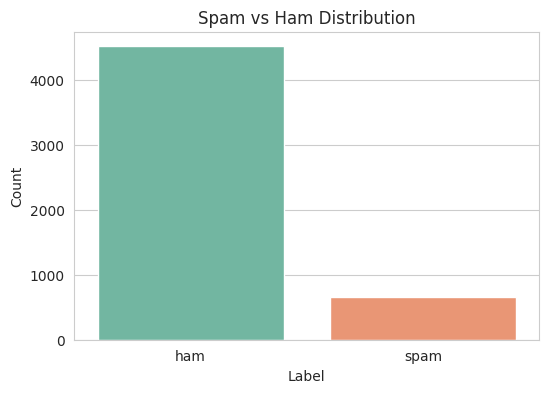

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=df,
    hue='label',
    palette='Set2',
    legend=False
)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

# Observation

The dataset contains two classes:

- Ham (Not Spam)
- Spam

Understanding class distribution helps us evaluate data balance before training machine learning models.

# Message Length Analysis

Calculate the number of characters in each message.

In [10]:
df['message_length'] = df['message'].apply(len)

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


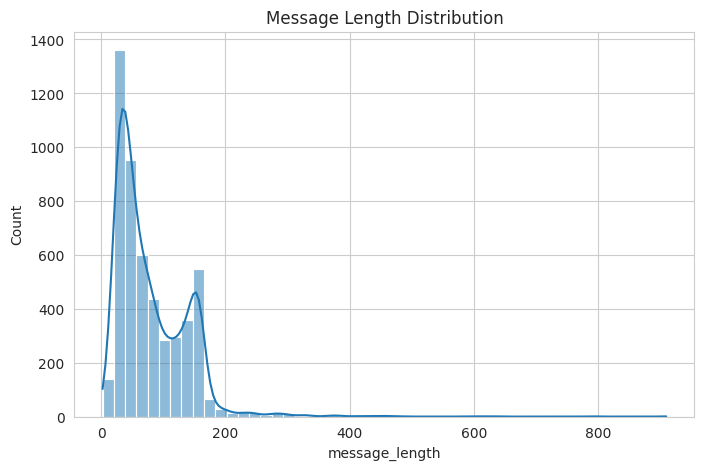

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['message_length'],
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")

plt.show()

# Text Preprocessing

The text undergoes several preprocessing steps:

- Convert to lowercase
- Remove punctuation
- Remove special characters
- Remove stopwords
- Apply stemming

In [12]:
ps = PorterStemmer()

corpus = []

for text in df['message']:

    review = re.sub(
        '[^a-zA-Z]',
        ' ',
        str(text)
    )

    review = review.lower()

    review = review.split()

    review = [
        ps.stem(word)
        for word in review
        if word not in stopwords.words('english')
    ]

    review = " ".join(review)

    corpus.append(review)

print("Text Cleaning Completed")

Text Cleaning Completed


# TF-IDF Vectorization

Convert textual messages into numerical features that machine learning models can understand.

In [13]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(corpus).toarray()

y = df['label']

# Train-Test Split

The dataset is divided into training and testing sets.

- 80% Training Data
- 20% Testing Data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Model 1: Naive Bayes

Train a Multinomial Naive Bayes classifier.

In [15]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train,
    y_train
)

nb_pred = nb_model.predict(X_test)

# Evaluate Naive Bayes Model

In [16]:
nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

print("Naive Bayes Accuracy:")
print(nb_accuracy)

print(
    classification_report(
        y_test,
        nb_pred
    )
)

Naive Bayes Accuracy:
0.9690522243713733
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       889
        spam       0.98      0.79      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034



# Naive Bayes Confusion Matrix

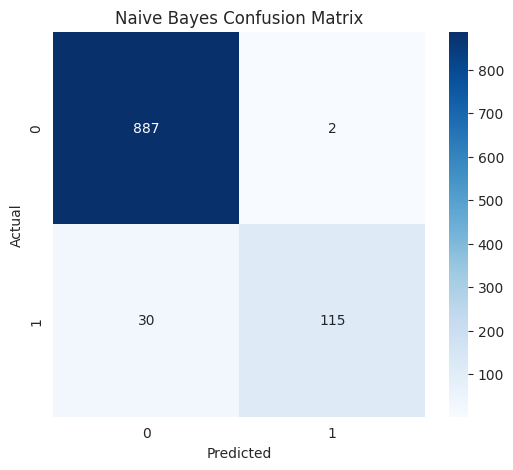

In [17]:
cm_nb = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Model 2: Logistic Regression

Train a Logistic Regression classifier.

In [18]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(X_test)

# Evaluate Logistic Regression

In [19]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression Accuracy:")
print(lr_accuracy)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy:
0.9564796905222437
              precision    recall  f1-score   support

         ham       0.96      0.99      0.98       889
        spam       0.95      0.73      0.82       145

    accuracy                           0.96      1034
   macro avg       0.95      0.86      0.90      1034
weighted avg       0.96      0.96      0.95      1034



# Logistic Regression Confusion Matrix

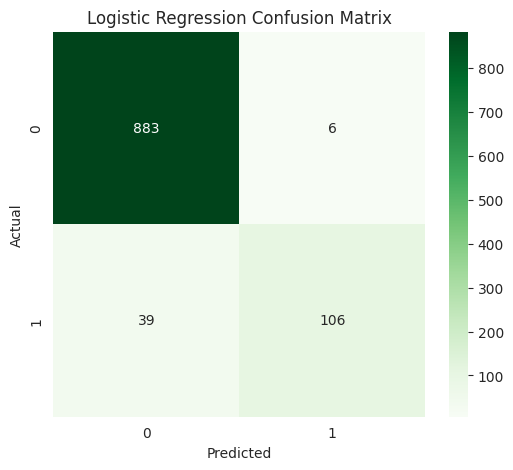

In [20]:
cm_lr = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Spam Word Cloud

Visualize the most frequent words appearing in spam messages.

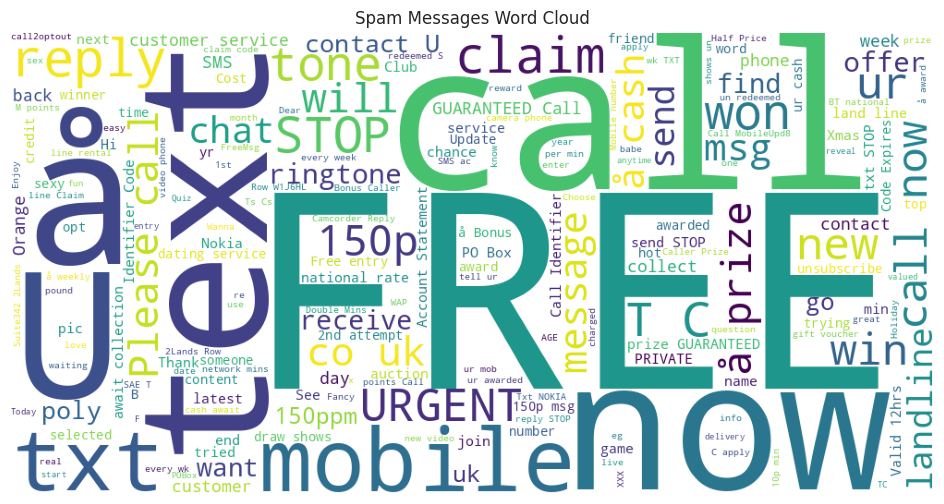

In [21]:
spam_text = " ".join(
    df[df['label']=="spam"]['message']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam Messages Word Cloud")

plt.show()

# Ham Word Cloud

Visualize the most frequent words appearing in legitimate messages.

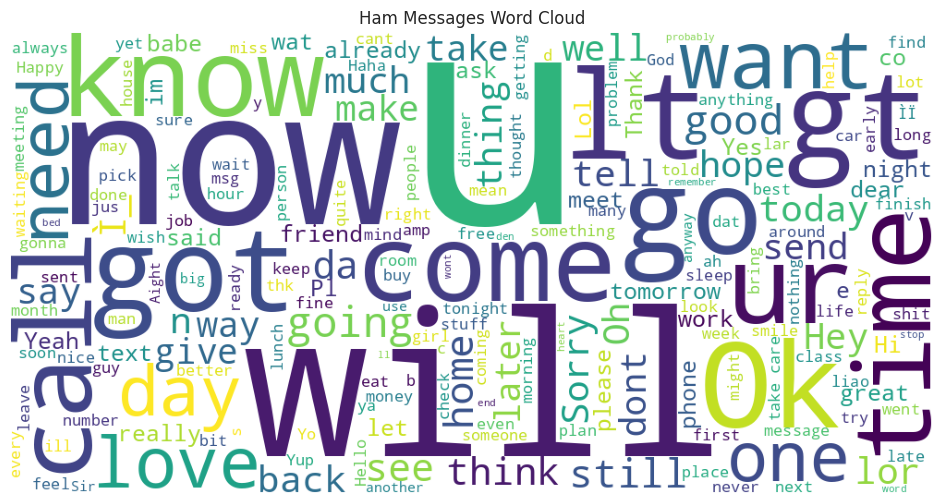

In [24]:
ham_text = " ".join(
    df[df['label']=="ham"]['message']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Ham Messages Word Cloud")

plt.show()

# Model Comparison

In [25]:
print("Naive Bayes Accuracy:", nb_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)

Naive Bayes Accuracy: 0.9690522243713733
Logistic Regression Accuracy: 0.9564796905222437


# Key Findings

1. Spam messages can be accurately identified using machine learning techniques.

2. Text preprocessing significantly improves model performance.

3. TF-IDF effectively converts text into numerical features.

4. Both Naive Bayes and Logistic Regression achieve high accuracy.

5. Logistic Regression generally provides slightly better classification performance.

# Business Recommendations

1. Implement spam filtering systems to reduce unwanted messages.



# Conclusion

This project successfully developed an Email Spam Detection system using Natural Language Processing and Machine Learning.

The results demonstrated that machine learning algorithms can effectively classify spam and legitimate messages.

This solution can help organizations improve communication security, reduce spam, and enhance user experience.